In [32]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor")
sys.path.append(str(project_path))

### Imports

In [33]:
from data_exploration.utils.data_loader import DataLoader
from data_exploration.utils.data_explorer import DataExplorer
from second_term_gpa_regression.utils.data_cleaner_proxy import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras
import tensorflow as tf
from keras_tuner import Hyperband
import shutil
import time

from tensorflow.keras.optimizers import Adam, SGD, RMSprop


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [34]:
# # Load the original student dataset 
# data_file = project_path / "data/Student data.csv"
# dl = DataLoader(str(data_file))
# structure_df = dl.load_and_clean_data()
# structure_df.columns.to_list()

#  # Save the cleaned dataset structure to a new CSV file
# structure_df.to_csv(project_path / "data/structured_student_data.csv", index=False)

In [35]:
# ------ Helper Classes for Custom Metrics ------
class RMSEMetric(tf.keras.metrics.Metric):
    """Dataset-level RMSE accumulated across batches."""

    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        squared_errors = tf.square(y_true - y_pred)
        self.sse.assign_add(tf.reduce_sum(squared_errors))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        return tf.sqrt(tf.math.divide_no_nan(self.sse, self.count))

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

class R2Metric(tf.keras.metrics.Metric):
    """Dataset-level R-squared metric accumulated across batches."""

    def __init__(self, name="r2", **kwargs):
        super().__init__(name=name, **kwargs)
        self.ss_res = self.add_weight(name="ss_res", initializer="zeros")
        self.sum_y = self.add_weight(name="sum_y", initializer="zeros")
        self.sum_y_sq = self.add_weight(name="sum_y_sq", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sum_y.assign_add(tf.reduce_sum(y_true))
        self.sum_y_sq.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        ss_tot = self.sum_y_sq - tf.square(self.sum_y) / (self.count + tf.keras.backend.epsilon())
        return 1.0 - tf.math.divide_no_nan(self.ss_res, ss_tot + tf.keras.backend.epsilon())

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

In [71]:
# ----- Helper Functions -----
def print_header(name):
    """Print a compact section header."""
    print("\n" + f" {name} ".center(72, "=") + "\n")


def custom_callback(monitor, mode, patience, filepath):
    """Early stopping and model checkpoint callbacks for training."""
    es = EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True, verbose=1, mode=mode)
    mc = ModelCheckpoint(filepath=filepath, monitor=monitor, verbose=1, save_best_only=True, mode=mode)
    return es, mc


def get_target_scale(scaler_obj=None):
    scaler_obj = scaler_obj or globals().get('scaler', None)
    if scaler_obj is None or not hasattr(scaler_obj, 'data_min_') or not hasattr(scaler_obj, 'data_max_'):
        return 1.0
    return float(np.asarray(scaler_obj.data_max_ - scaler_obj.data_min_).ravel()[0])


def plot_regression_history(history, title_prefix='Model', scaler_obj=None):
    target_scale = get_target_scale(scaler_obj)
    mse_scale = target_scale ** 2

    train_mae = np.asarray(history.history['mae']) * target_scale
    val_mae = np.asarray(history.history['val_mae']) * target_scale
    train_loss = np.asarray(history.history['loss']) * mse_scale
    val_loss = np.asarray(history.history['val_loss']) * mse_scale

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(train_mae, label='Train MAE')
    axes[0].plot(val_mae, label='Val MAE')
    axes[0].set(title=f'{title_prefix} MAE', xlabel='Epoch', ylabel='MAE (GPA)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_loss, label='Train Loss')
    axes[1].plot(val_loss, label='Val Loss')
    if 'rmse' in history.history:
        axes[1].plot(np.asarray(history.history['rmse']) * target_scale, '--', label='Train RMSE')
        axes[1].plot(np.asarray(history.history['val_rmse']) * target_scale, '--', label='Val RMSE')
    axes[1].set(title=f'{title_prefix} Loss & RMSE', xlabel='Epoch', ylabel='Value (GPA / GPA²)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if 'r2' in history.history:
        axes[2].plot(history.history['r2'], label='Train R² (Scaled y)')
        axes[2].plot(history.history['val_r2'], label='Val R² (Scaled y)')
        axes[2].set(title=f'{title_prefix} R² (Scaled y)', xlabel='Epoch', ylabel='R²')
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best = int(np.argmin(history.history['val_loss']))
    get = lambda values: f"{np.asarray(values)[best]:.4f}"

    print(f"\nBest Epoch: {best + 1}")
    print('-' * 40)
    print(f"MAE (GPA)   -> Train: {get(train_mae)} | Val: {get(val_mae)}")
    if 'rmse' in history.history:
        print(f"RMSE (GPA)  -> Train: {get(np.asarray(history.history['rmse']) * target_scale)} | Val: {get(np.asarray(history.history['val_rmse']) * target_scale)}")
    print(f"Loss (GPA²) -> Train: {get(train_loss)} | Val: {get(val_loss)}")
    if 'r2' in history.history:
        print(f"R² (Scaled y) -> Train: {get(history.history['r2'])} | Val: {get(history.history['val_r2'])}")


def get_optimizer(name, learning_rate):
    if name == 'adam':
        return Adam(learning_rate=learning_rate)
    if name == 'sgd':
        return SGD(learning_rate=learning_rate, momentum=0.9)
    if name == 'rmsprop':
        return RMSprop(learning_rate=learning_rate)
    raise ValueError(f'Unsupported optimizer: {name}')


def build_dense_model(input_dim, layer_specs):
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])
    for spec in layer_specs:
        model.add(Dense(spec['units'], activation=spec['activation']))
        if spec.get('batch_norm', False):
            model.add(BatchNormalization())
        if spec.get('dropout', 0.0) > 0:
            model.add(Dropout(spec['dropout']))
    model.add(Dense(1))
    return model


def compile_regression_model(model, optimizer_name, learning_rate):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='mse',
        metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
    )
    return model


def inverse_transform_target(values, scaler):
    return scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).flatten()


def evaluate_model_original_scale(model, X_split, y_split, scaler, split_name='Split', verbose=0, print_summary=True):
    y_pred_scaled = model.predict(X_split, verbose=verbose).ravel()
    y_true_scaled = np.asarray(y_split).ravel()
    y_true_actual = inverse_transform_target(y_split, scaler)
    y_pred_actual = inverse_transform_target(y_pred_scaled, scaler)
    r2_original = float(r2_score(y_true_actual, y_pred_actual))
    r2_scaled = float(r2_score(y_true_scaled, y_pred_scaled))

    metrics = {
        'split': split_name,
        'rmse': float(mean_squared_error(y_true_actual, y_pred_actual) ** 0.5),
        'mse': float(mean_squared_error(y_true_actual, y_pred_actual)),
        'mae': float(mean_absolute_error(y_true_actual, y_pred_actual)),
        'r2_original': r2_original,
        'r2_scaled': r2_scaled,
    }

    if print_summary:
        print(f"{split_name} RMSE: {metrics['rmse']:.4f}")
        print(f"{split_name} MSE:  {metrics['mse']:.4f}")
        print(f"{split_name} MAE:              {metrics['mae']:.4f}")
        print(f"{split_name} R² (Original GPA): {metrics['r2_original']:.4f}")
        print(f"{split_name} R² (Scaled y):     {metrics['r2_scaled']:.4f}")

    prediction_df = pd.DataFrame({
        'Actual GPA': y_true_actual,
        'Predicted GPA': y_pred_actual,
    })
    prediction_df['Residual'] = prediction_df['Actual GPA'] - prediction_df['Predicted GPA']
    prediction_df['Absolute Error'] = prediction_df['Residual'].abs()
    prediction_df['Squared Error'] = prediction_df['Residual'] ** 2
    prediction_df = prediction_df.sort_values('Absolute Error', ascending=False).reset_index(drop=True)

    return metrics, prediction_df


def format_metrics_display(df):
    return df.rename(columns={
        'rmse': 'RMSE (GPA)',
        'mse': 'MSE (GPA²)',
        'mae': 'MAE (GPA)',
        'r2_original': 'R² (Original GPA)',
        'r2_scaled': 'R² (Scaled y)',
    })


def format_local_search_display(df):
    return df.rename(columns={
        'trial': 'Trial',
        'trial_name': 'Trial Name',
        'optimizer': 'Optimizer',
        'learning_rate': 'Learning Rate',
        'batch_size': 'Batch Size',
        'best_epoch': 'Best Epoch',
        'val_rmse': 'Val RMSE (GPA)',
        'val_mae': 'Val MAE (GPA)',
        'val_r2_original': 'Val R² (Original GPA)',
        'val_r2_scaled': 'Val R² (Scaled y)',
        'test_rmse': 'Test RMSE (GPA)',
        'test_mae': 'Test MAE (GPA)',
        'test_r2_original': 'Test R² (Original GPA)',
        'test_r2_scaled': 'Test R² (Scaled y)',
        'architecture': 'Architecture',
    })


def plot_prediction_diagnostics(prediction_df, title_prefix='Model'):
    actual = prediction_df['Actual GPA']
    predicted = prediction_df['Predicted GPA']
    residuals = prediction_df['Residual']
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(x=actual, y=predicted, color='#4c78a8', alpha=0.65, ax=axes[0])
    axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'r--', linewidth=1.5)
    axes[0].set_title(f'{title_prefix}: Actual vs Predicted')
    axes[0].set_xlabel('Actual GPA')
    axes[0].set_ylabel('Predicted GPA')
    axes[0].set_xlim(plot_min, plot_max)
    axes[0].set_ylim(plot_min, plot_max)
    axes[0].grid(True, alpha=0.3)

    sns.scatterplot(x=predicted, y=residuals, color='#f58518', alpha=0.65, ax=axes[1])
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
    axes[1].set_title(f'{title_prefix}: Residuals vs Predicted')
    axes[1].set_xlabel('Predicted GPA')
    axes[1].set_ylabel('Residual')
    axes[1].grid(True, alpha=0.3)

    sns.histplot(residuals, bins=20, kde=True, color='#54a24b', ax=axes[2])
    axes[2].axvline(0, color='red', linestyle='--', linewidth=1.2)
    axes[2].set_title(f'{title_prefix}: Residual Distribution')
    axes[2].set_xlabel('Residual')
    axes[2].set_ylabel('Count')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_experiment_comparison(comparison_df):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.barplot(data=comparison_df, x='Model', y='r2_original', hue='Split', palette='Blues', ax=axes[0])
    axes[0].set_title('R² Comparison (Original GPA)')
    axes[0].set_ylabel('R²')
    axes[0].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='r2_scaled', hue='Split', palette='Greens', ax=axes[1])
    axes[1].set_title('R² Comparison (Scaled y)')
    axes[1].set_ylabel('R²')
    axes[1].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='rmse', hue='Split', palette='Oranges', ax=axes[2])
    axes[2].set_title('RMSE Comparison')
    axes[2].set_ylabel('RMSE (GPA)')
    axes[2].grid(True, axis='y', alpha=0.3)

    axes[1].legend_.remove()
    axes[2].legend_.remove()
    for ax in axes:
        ax.tick_params(axis='x', rotation=12)

    plt.tight_layout()
    plt.show()


def plot_local_search_summary(local_search_results_df, top_n=8):
    plot_df = local_search_results_df.copy()
    top_df = plot_df.head(top_n).copy().sort_values('val_r2_original')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.scatterplot(
        data=plot_df,
        x='val_rmse',
        y='val_r2_original',
        hue='optimizer',
        size='best_epoch',
        sizes=(60, 220),
        palette='viridis',
        ax=axes[0],
    )
    axes[0].set_title('Local Search: Validation RMSE vs R² (Original GPA)')
    axes[0].set_xlabel('Validation RMSE (GPA)')
    axes[0].set_ylabel('Validation R² (Original GPA)')
    axes[0].grid(True, alpha=0.3)

    sns.barplot(data=top_df, x='val_r2_original', y='trial_name', hue='optimizer', dodge=False, palette='Blues', ax=axes[1])
    axes[1].set_title(f'Top {top_n} Local Search Trials')
    axes[1].set_xlabel('Validation R² (Original GPA)')
    axes[1].set_ylabel('Trial')
    axes[1].grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_feature_groups(feature_columns):
    base_features = [
        'first_term_gpa',
        'high_school_average_mark',
        'math_score',
        'fast_track',
        'coop',
        'residency',
        'age_group',
        'english_grade',
        'first_language',
        'funding',
        'gender',
        'previous_education',
        'gpa_category',
    ]
    grouped = {}
    assigned = set()

    for feature in base_features:
        cols = [
            col for col in feature_columns
            if col == feature or (col.startswith(f'{feature}_') and not col.endswith('_missing'))
        ]
        if cols:
            grouped[feature] = cols
            assigned.update(cols)

    missing_flag_cols = [col for col in feature_columns if col.endswith('_missing')]
    for col in missing_flag_cols:
        grouped[col] = [col]
        assigned.add(col)

    for col in feature_columns:
        if col not in assigned:
            grouped[col] = [col]

    return grouped


def compute_grouped_permutation_importance(model, X_df, y_scaled, scaler, n_repeats=3, random_state=42, verbose=0):
    feature_groups = get_feature_groups(list(X_df.columns))
    rng = np.random.default_rng(random_state)
    y_true_actual = inverse_transform_target(y_scaled, scaler)
    baseline_pred_actual = inverse_transform_target(model.predict(X_df, verbose=verbose).ravel(), scaler)
    baseline_rmse = mean_squared_error(y_true_actual, baseline_pred_actual) ** 0.5
    baseline_r2 = r2_score(y_true_actual, baseline_pred_actual)

    rows = []
    for group_name, columns in feature_groups.items():
        rmse_increases = []
        r2_drops = []
        for _ in range(n_repeats):
            X_permuted = X_df.copy()
            perm_idx = rng.permutation(len(X_permuted))
            X_permuted.loc[:, columns] = X_permuted.iloc[perm_idx][columns].to_numpy()
            perm_pred_actual = inverse_transform_target(model.predict(X_permuted, verbose=verbose).ravel(), scaler)
            perm_rmse = mean_squared_error(y_true_actual, perm_pred_actual) ** 0.5
            perm_r2 = r2_score(y_true_actual, perm_pred_actual)
            rmse_increases.append(perm_rmse - baseline_rmse)
            r2_drops.append(baseline_r2 - perm_r2)

        rows.append({
            'Feature Group': group_name,
            'RMSE Increase (Mean)': float(np.mean(rmse_increases)),
            'RMSE Increase (Std)': float(np.std(rmse_increases)),
            'R² Drop (Mean)': float(np.mean(r2_drops)),
            'Grouped Columns': ', '.join(columns),
        })

    importance_df = pd.DataFrame(rows).sort_values(['RMSE Increase (Mean)', 'R² Drop (Mean)'], ascending=False).reset_index(drop=True)
    return importance_df


def plot_grouped_feature_importance(importance_df, title='Grouped Feature Importance'):
    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=importance_df.sort_values('RMSE Increase (Mean)'),
        x='RMSE Increase (Mean)',
        y='Feature Group',
        hue='Feature Group',
        palette='crest',
        dodge=False,
        legend=False,
    )
    plt.title(title)
    plt.xlabel('Mean RMSE Increase after Group Permutation')
    plt.ylabel('Feature Group')
    plt.tight_layout()
    plt.show()

### Data Acquisition

In [37]:
#----- Main Code -----#
np.random.seed(42)

# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [38]:
# Check the dataset by replacing ? with NaN and drop duplicates -- Cleaning is conducted later by the DataCleaner class
temp_df = clean_df
temp_df = temp_df.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
skim(temp_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ float64     │ 15    │                                                          │
│ │ Number of columns │ 15     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %              ┃ mean   ┃ sd     ┃ p0 ┃ p25  ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa     │  17 │ 1.183020180932498 │  2.846 │  1.175 │  0 │ 2.25 │ 3.103 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │                    │     │                 3 │        │        │    │      │       │       │      │        │  │
│ │ second_term_gpa    │ 160 │ 11.13430758524704 │   2.82 │  1.129 │  0 │ 2.26 │ 3.028 │  3.68 │  4.5 │ ▂▁▃▆▇▆ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ first_language     │ 111 │ 7.724425887265136 │  1.911 │ 0.9949 │  1 │    1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │ funding            │   0 │                 0 │  2.927 │  1.258 │  1 │    2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ school             │   0 │                 0 │      6 │      0 │  6 │    6 │     6 │     6 │    6 │     ▇  │  │
│ │ fast_track         │   0 │                 0 │  1.742 │ 0.4378 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ coop               │   0 │                 0 │  1.695 │ 0.4605 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ residency          │   0 │                 0 │  1.406 │ 0.4913 │  1 │    1 │     1 │     2 │    2 │ ▇    ▅ │  │
│ │ gender             │   0 │                 0 │  1.775 │ 0.4197 │  1 │    2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education │   4 │ 0.278357689631176 │  1.275 │ 0.5678 │  0 │    1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ age_group          │   4 │ 0.278357689631176 │  2.632 │  1.421 │  1 │    2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ high_school_averag │ 743 │ 51.70494084899095 │  77.15 │  12.07 │ 17 │   70 │  77.5 │    85 │  108 │   ▂▇▇▂ │  │
│ │ e_mark             │     │                   │        │        │    │      │       │       │      │        │  │
│ │ math_score         │ 462 │ 32.15031315240083 │  32.56 │  10.71 │  6 │   23 │    32 │    43 │   50 │ ▁▅▇▇▅▇ │  │
│ │                    │     │                 4 │        │        │    │      │       │       │      │        │  │
│ │ english_grade      │  45 │ 3.131524008350730 │   8.03 │  1.716 │  1 │    7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                    │     │                 5 │        │        │    │      │       │       │      │        │  │
│ │ first_year_persist │   0 │                 0 │ 0.7919 │ 0.4061 │  0 │    1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ ence               │     │                   │      

In [39]:
# replace ? with nan in second_term_gpa column
clean_df["first_term_gpa"] = clean_df["first_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Number of rows with nulls in first_term_gpa: {clean_df['first_term_gpa'].isna().sum()}")
print(f"Number of rows with nulls in second_term_gpa: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
clean_df = clean_df.dropna(subset=["first_term_gpa"])
print(f"Number of rows after dropping nulls in both first and second term GPA variables: {clean_df.shape[0]}")

Number of rows with nulls in first_term_gpa: 17
Number of rows with nulls in second_term_gpa: 160
Number of rows after dropping nulls in both first and second term GPA variables: 1277


In [40]:
# Synthetic proxy for third-term GPA (relay model):
# Weighted progression from first- and second-term GPA,
# conditioned on first-year persistence (non-persistent students assigned 0)
clean_df["third_term_gpa_proxy"] = (
    0.6 * clean_df["second_term_gpa"] + 0.4 * clean_df["first_term_gpa"]
) * clean_df["first_year_persistence"]

# Feature and target separation
y = clean_df["third_term_gpa_proxy"] # third_term_gpa_proxy 
X = clean_df.drop(columns=["school", "third_term_gpa_proxy"]) # Drop school - unique value; avoid target variable for relay version

### Data Exploration

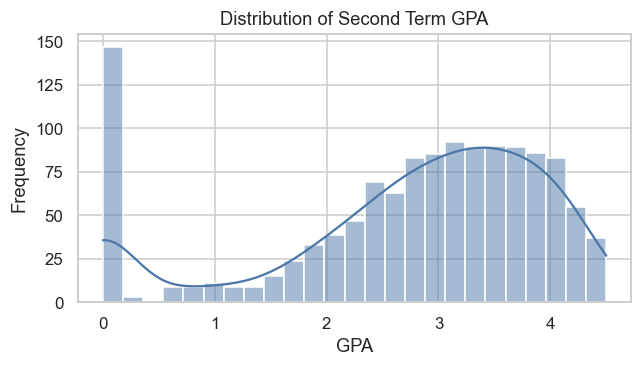

In [41]:
# explorer = DataExplorer(structured_data_file)
# explorer.run_full_analysis()

# Analyze target variable distribution
plt.figure(figsize=(6,3.5))

sns.histplot(y, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Second Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [42]:
# number of students have value 0 in second_term_gpa column
num_zero_gpa = (y == 0).sum()
print(f"Number of students with second term GPA of 0: {num_zero_gpa}")

Number of students with second term GPA of 0: 145


### Train-Test Protocol

In [43]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (893, 14), X_val: (128, 14), X_test: (256, 14)


In [44]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,second_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence
78,3.521739,3.288462,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7,1.0
353,2.250000,2.200000,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7,1.0
1354,3.400000,3.386364,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8,1.0
510,4.214286,4.152174,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9,1.0
338,2.547619,2.891304,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9,0.0


### Data Cleaning

In [45]:
# Data cleaning
cleaner = DataCleaner(numeric_imputer="bayesian")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

# Target standardization
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test = scaler.transform(y_test.values.reshape(-1, 1)).flatten()


In [46]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner, project_path / "second_term_gpa_regression" / "models" / "best_model" / "preprocessing_pipeline.pkl")
joblib.dump(scaler, project_path / "second_term_gpa_regression" / "models" / "best_model" / "target_scaler.pkl")

# check the training after cleaning
display(X_train.head())

,first_term_gpa,second_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,...,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3,gpa_category_0,gpa_category_1,gpa_category_2,gpa_category_3
78,0.486738,0.416722,1,0,0,3.0,0.338587,0.254614,7.0,1.0,...,True,False,False,True,False,False,False,False,False,True
353,-0.764013,-0.525718,0,0,1,2.0,0.250235,0.103456,7.0,1.0,...,False,True,False,False,True,False,False,False,True,False
1354,0.367008,0.501490,1,0,0,4.0,0.300803,0.230263,8.0,1.0,...,True,False,False,False,True,False,False,False,False,True
510,1.167855,1.164563,0,1,1,4.0,-0.772696,1.662716,9.0,1.0,...,False,True,False,False,True,False,False,False,False,True
338,-0.471306,0.072844,0,1,1,2.0,-0.261231,-0.712049,9.0,0.0,...,False,True,False,True,False,False,False,False,True,False


### Experiment 1: Baseline Model

In [47]:
baseline_layers = [
    {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 32, 'activation': 'relu', 'batch_norm': False, 'dropout': 0.0},
]

baseline_model = build_dense_model(X_train.shape[1], baseline_layers)
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │           5,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,385 (64.00 KB)

 Trainable params: 16,001 (62.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [48]:
baseline_model = compile_regression_model(baseline_model, optimizer_name='adam', learning_rate=0.001)

baseline_es, baseline_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'regression_model.keras',
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[baseline_es, baseline_mc],
    verbose=1,
)

Epoch 1/200
22/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2826 - mae: 0.8539 - r2: -15.6753 - rmse: 1.1218
Epoch 1: val_loss improved from None to 0.26583, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.8519 - mae: 0.7015 - r2: -9.3415 - rmse: 0.9230 - val_loss: 0.2658 - val_mae: 0.4685 - val_r2: -2.3727 - val_rmse: 0.5156
Epoch 2/200
20/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4613 - mae: 0.5269 - r2: -4.4670 - rmse: 0.6788
Epoch 2: val_loss improved from 0.26583 to 0.10371, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras

Ep

### Baseline Evaluation

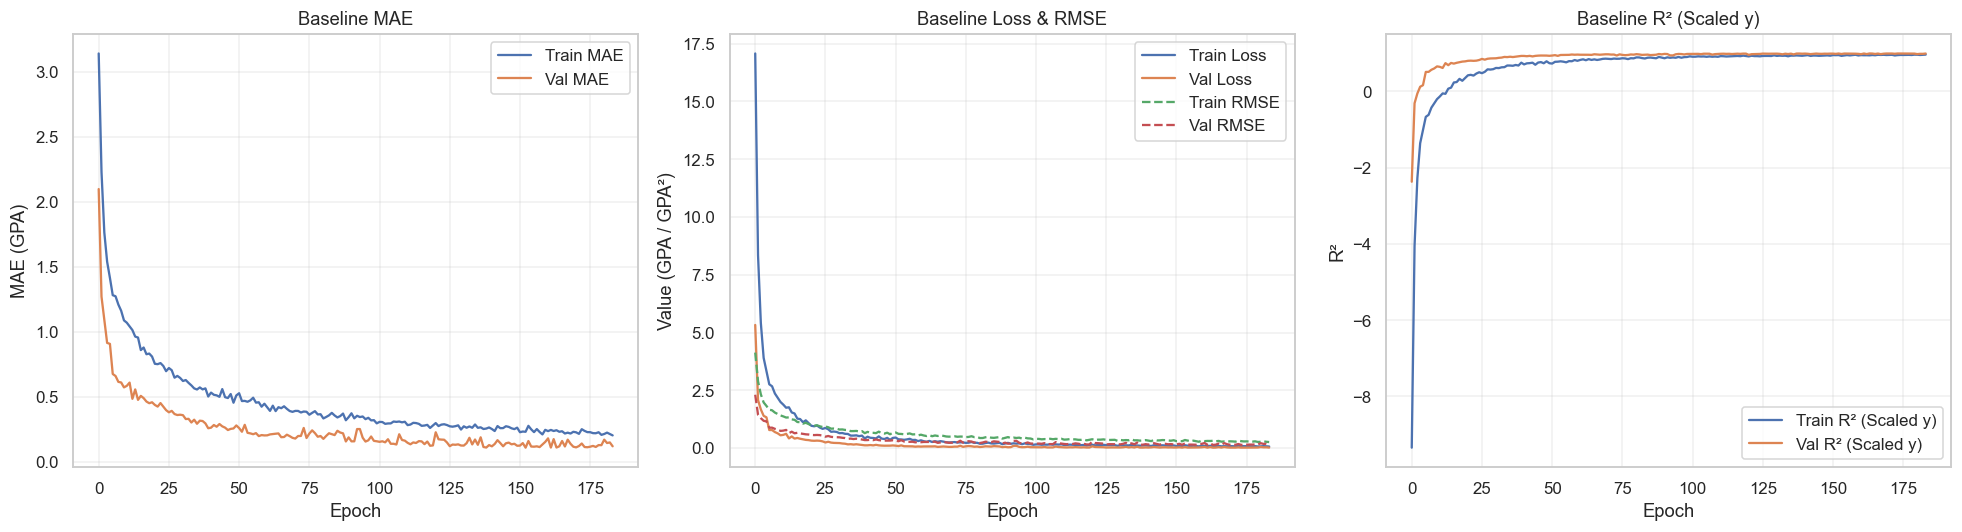


Best Epoch: 164
----------------------------------------
MAE (GPA)   -> Train: 0.2422 | Val: 0.1091
RMSE (GPA)  -> Train: 0.3163 | Val: 0.1368
Loss (GPA²) -> Train: 0.1000 | Val: 0.0187
R² (Scaled y) -> Train: 0.9394 | Val: 0.9881


In [49]:
plot_regression_history(history_baseline, title_prefix='Baseline')

In [50]:
baseline_val_metrics, baseline_val_df = evaluate_model_original_scale(
    baseline_model, X_val, y_val, scaler, split_name='Baseline Validation'
)
baseline_test_metrics, baseline_test_df = evaluate_model_original_scale(
    baseline_model, X_test, y_test, scaler, split_name='Baseline Test'
)

baseline_summary_df = pd.DataFrame([baseline_val_metrics, baseline_test_metrics]).set_index('split')
display(format_metrics_display(baseline_summary_df))
display(baseline_test_df.head(15))

Baseline Validation RMSE: 0.1368
Baseline Validation MSE:  0.0187
Baseline Validation MAE:              0.1091
Baseline Validation R² (Original GPA): 0.9881
Baseline Validation R² (Scaled y):     0.9881
Baseline Test RMSE: 0.1450
Baseline Test MSE:  0.0210
Baseline Test MAE:              0.1154
Baseline Test R² (Original GPA): 0.9854
Baseline Test R² (Scaled y):     0.9854


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline Validation,0.136825,0.018721,0.109105,0.988149,0.988149
Baseline Test,0.145019,0.021030,0.115393,0.985360,0.985360


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,1.650000,1.145941,0.504059,0.504059,0.254076
1,1.780563,1.360072,0.420490,0.420490,0.176812
2,2.844393,2.484179,0.360214,0.360214,0.129754
3,1.342857,1.695280,-0.352423,0.352423,0.124202
4,2.584980,2.234077,0.350903,0.350903,0.123133
5,3.152402,3.482411,-0.330009,0.330009,0.108906
6,3.329473,3.658268,-0.328794,0.328794,0.108106
7,2.448190,2.771649,-0.323458,0.323458,0.104625
8,2.989273,3.308305,-0.319032,0.319032,0.101781
9,1.222222,0.903477,0.318745,0.318745,0.101599


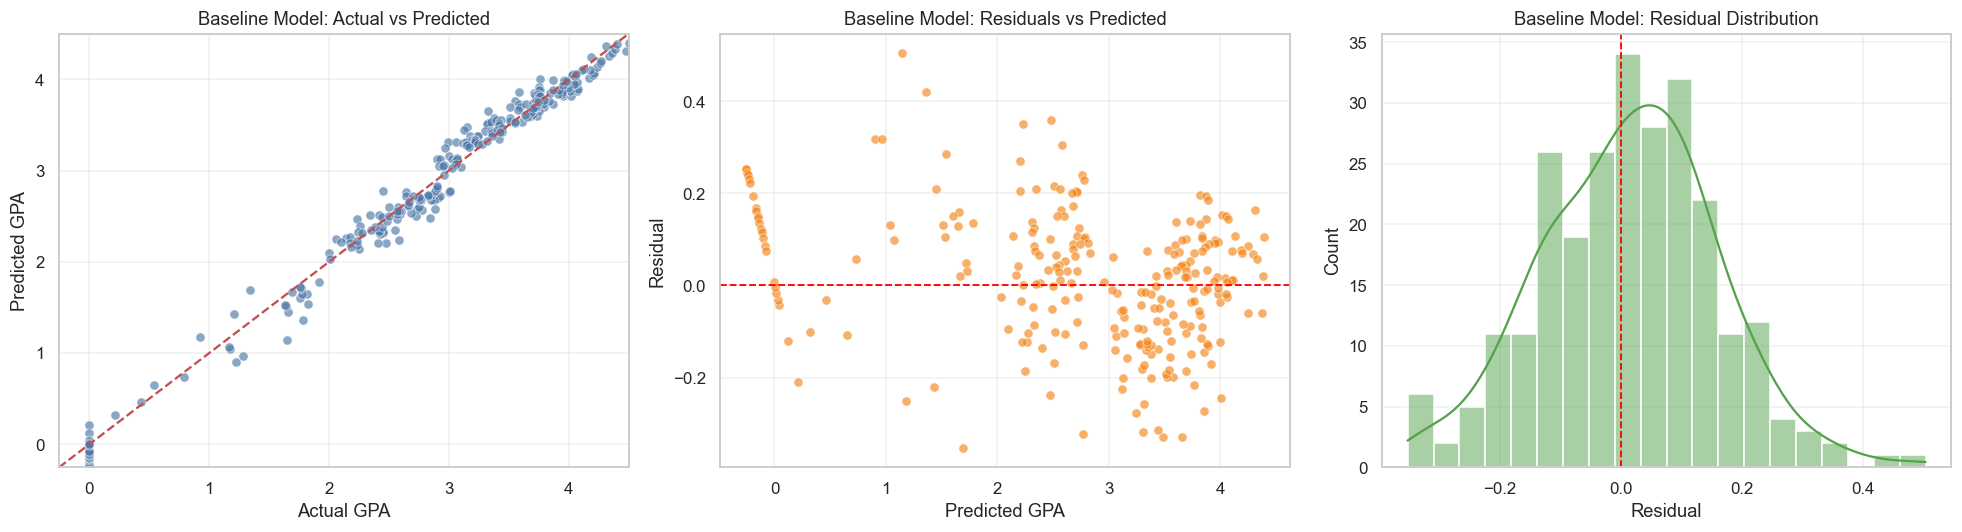

In [51]:
plot_prediction_diagnostics(baseline_test_df, title_prefix='Baseline Model')

### Experiment 2: Keras Tuner - Automatic Hyperband Search

In [ ]:
def build_tuner_model(hp):
    layer_specs = []
    num_layers = hp.Int('num_layers', 1, 5)

    for i in range(num_layers):
        layer_specs.append({
            'units': hp.Choice(f'neurons_{i}', [64, 128, 256, 512, 1024]),
            'activation': hp.Choice(f'act_{i}', ['relu', 'tanh', 'elu']),
            'batch_norm': True,
            'dropout': hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1),
        })

    tuner_model = build_dense_model(X_train.shape[1], layer_specs)
    optimizer_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])
    learning_rate = hp.Choice('learning_rate', [0.0001, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.01])
    tuner_model = compile_regression_model(tuner_model, optimizer_name=optimizer_name, learning_rate=learning_rate)
    return tuner_model


def show_best_hyperparameters(hyperparameters):
    rows = [{'hyperparameter': k, 'value': v} for k, v in hyperparameters.values.items()]
    display(pd.DataFrame(rows))

In [53]:
tuner_dir = project_path / 'second_term_gpa_regression' / 'tuner' / 'student_tuner'
if tuner_dir.exists():
    shutil.rmtree(tuner_dir, ignore_errors=True)

print_header('KERAS TUNER SEARCH')

hyperband_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective='val_loss',
    max_epochs=40,
    factor=3,
    directory=tuner_dir,
    project_name='student_tuner',
    seed=42,
    overwrite=True,
)

search_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0,
    mode='min',
)

search_start = time.time()
hyperband_tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    callbacks=[search_stop],
    verbose=1,
)
search_time = time.time() - search_start

print(f'Search completed in {search_time / 60:.1f} minutes')
hyperband_tuner.results_summary(num_trials=10)

best_hps = hyperband_tuner.get_best_hyperparameters(1)[0]
print_header('BEST HYPERPARAMETERS')
show_best_hyperparameters(best_hps)

Trial 90 Complete [00h 00m 22s]
val_loss: 0.014930110424757004

Best val_loss So Far: 0.0008999102283269167
Total elapsed time: 00h 11m 52s
Search completed in 11.9 minutes
Results summary
Results in C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\tuner\student_tuner\student_tuner
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0082 summary
Hyperparameters:
num_layers: 2
neurons_0: 256
act_0: tanh
dropout_0: 0.2
optimizer: adam
learning_rate: 0.01
neurons_1: 128
act_1: elu
dropout_1: 0.4
neurons_2: 128
act_2: elu
dropout_2: 0.5
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0080
Score: 0.0008999102283269167

Trial 0050 summary
Hyperparameters:
num_layers: 1
neurons_0: 64
act_0: relu
dropout_0: 0.4
optimizer: adam
learning_rate: 0.005
neurons_1: 512
act_1: tanh
dropout_1: 0.2
neurons_2: 512
act_2: tanh
dropout_2: 0.1
tuner/epochs: 40
tuner/initial_epoch

,hyperparameter,value
0,num_layers,2
1,neurons_0,256
2,act_0,tanh
3,dropout_0,0.2
4,optimizer,adam
5,learning_rate,0.01
6,neurons_1,128
7,act_1,elu
8,dropout_1,0.4
9,neurons_2,128


### Hyperband Results

In [54]:
all_trials = list(hyperband_tuner.oracle.trials.values())
target_scale = get_target_scale(scaler)
mse_scale = target_scale ** 2

tuning_results_df = pd.DataFrame([
    {
        'Loss (GPA²)': (t.metrics.metrics['loss'].get_best_value() * mse_scale) if 'loss' in t.metrics.metrics else None,
        'Val_Loss (GPA²)': (t.metrics.metrics['val_loss'].get_best_value() * mse_scale) if 'val_loss' in t.metrics.metrics else None,
        'MAE (GPA)': (t.metrics.metrics['mae'].get_best_value() * target_scale) if 'mae' in t.metrics.metrics else None,
        'Val_MAE (GPA)': (t.metrics.metrics['val_mae'].get_best_value() * target_scale) if 'val_mae' in t.metrics.metrics else None,
        'RMSE (GPA)': (t.metrics.metrics['rmse'].get_best_value() * target_scale) if 'rmse' in t.metrics.metrics else None,
        'Val_RMSE (GPA)': (t.metrics.metrics['val_rmse'].get_best_value() * target_scale) if 'val_rmse' in t.metrics.metrics else None,
        'R2 (Scaled y)': t.metrics.metrics['r2'].get_best_value() if 'r2' in t.metrics.metrics else None,
        'Val_R2 (Scaled y)': t.metrics.metrics['val_r2'].get_best_value() if 'val_r2' in t.metrics.metrics else None,
        **t.hyperparameters.values,
    }
    for t in all_trials
]).sort_values('Val_Loss (GPA²)', ascending=True).reset_index(drop=True)

tuning_results_df.insert(0, 'ID', range(1, len(tuning_results_df) + 1))
tuning_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'keras_tuner_results_regression_bayesian.csv',
    index=False,
)

print('TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)')
print(tuning_results_df.head(20).to_string(index=False))

TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)
 ID  Loss (GPA²)  Val_Loss (GPA²)  MAE (GPA)  Val_MAE (GPA)  RMSE (GPA)  Val_RMSE (GPA)  R2 (Scaled y)  Val_R2 (Scaled y)  num_layers  neurons_0 act_0  dropout_0 optimizer  learning_rate  tuner/epochs  tuner/initial_epoch  tuner/bracket  tuner/round  neurons_1 act_1  dropout_1  neurons_2 act_2  dropout_2 tuner/trial_id
  1     0.130588         0.018037   0.274932       0.096377    0.361370        0.134301       0.920904           0.988582           2        256  tanh        0.2      adam          0.010            40                   14              1            1        128   elu        0.4      128.0   elu        0.5           0080
  2     0.189335         0.018072   0.340438       0.086109    0.435127        0.134431       0.885321           0.988560           1         64  relu        0.4      adam          0.005            40                   14              3            3        512  tanh        0.2      51

In [55]:
best_model = hyperband_tuner.hypermodel.build(best_hps)
best_model.summary()

best_es, best_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_regression_model_bayesian.keras',
)

history_best = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[best_es, best_mc],
    verbose=1,
)

print('Training completed.')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 256)                 │          10,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 45,057 (176.00 KB)

 Trainable params: 44,289 (173.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7307 - mae: 1.3688 - r2: -46.3397 - rmse: 1.8790
Epoch 1: val_loss improved from None to 0.28255, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 1.8861 - mae: 0.9240 - r2: -21.8965 - rmse: 1.3733 - val_loss: 0.2825 - val_mae: 0.4647 - val_r2: -2.5848 - val_rmse: 0.5316
Epoch 2/200
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3294 - mae: 0.4194 - r2: -3.1193 - rmse: 0.5726
Epoch 2: val_loss improved from 0.28255 to 0.03233, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\mode

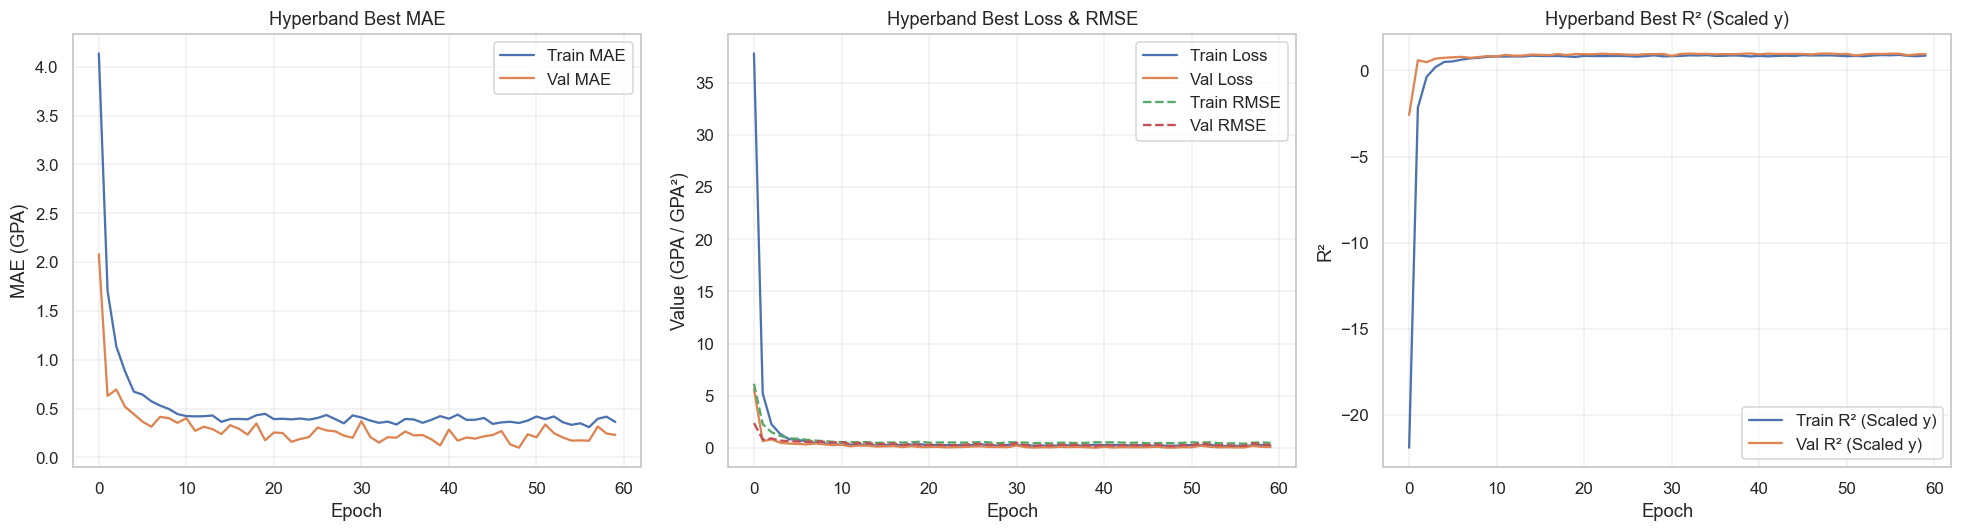


Best Epoch: 40
----------------------------------------
MAE (GPA)   -> Train: 0.4223 | Val: 0.1221
RMSE (GPA)  -> Train: 0.5576 | Val: 0.1589
Loss (GPA²) -> Train: 0.3109 | Val: 0.0252
R² (Scaled y) -> Train: 0.8117 | Val: 0.9840


In [56]:
plot_regression_history(history_best, title_prefix='Hyperband Best')

In [57]:
best_val_metrics, best_val_df = evaluate_model_original_scale(
    best_model, X_val, y_val, scaler, split_name='Hyperband Validation'
)
best_test_metrics, best_test_df = evaluate_model_original_scale(
    best_model, X_test, y_test, scaler, split_name='Hyperband Test'
)

best_summary_df = pd.DataFrame([best_val_metrics, best_test_metrics]).set_index('split')
display(format_metrics_display(best_summary_df))
display(best_test_df.head(15))

Hyperband Validation RMSE: 0.1589
Hyperband Validation MSE:  0.0252
Hyperband Validation MAE:              0.1221
Hyperband Validation R² (Original GPA): 0.9840
Hyperband Validation R² (Scaled y):     0.9840
Hyperband Test RMSE: 0.1628
Hyperband Test MSE:  0.0265
Hyperband Test MAE:              0.1279
Hyperband Test R² (Original GPA): 0.9816
Hyperband Test R² (Scaled y):     0.9816


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Hyperband Validation,0.158865,0.025238,0.122056,0.984024,0.984024
Hyperband Test,0.162781,0.026498,0.127885,0.981553,0.981553


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,-0.642568,0.642568,0.642568,0.412893
1,0.217391,0.851476,-0.634084,0.634084,0.402063
2,3.612879,3.099763,0.513115,0.513115,0.263287
3,0.540000,1.025124,-0.485124,0.485124,0.235345
4,0.000000,-0.456438,0.456438,0.456438,0.208336
5,0.428572,0.843484,-0.414913,0.414913,0.172153
6,0.000000,-0.360799,0.360799,0.360799,0.130176
7,0.000000,-0.321780,0.321780,0.321780,0.103542
8,4.030020,3.715924,0.314097,0.314097,0.098657
9,4.049833,3.736100,0.313733,0.313733,0.098428


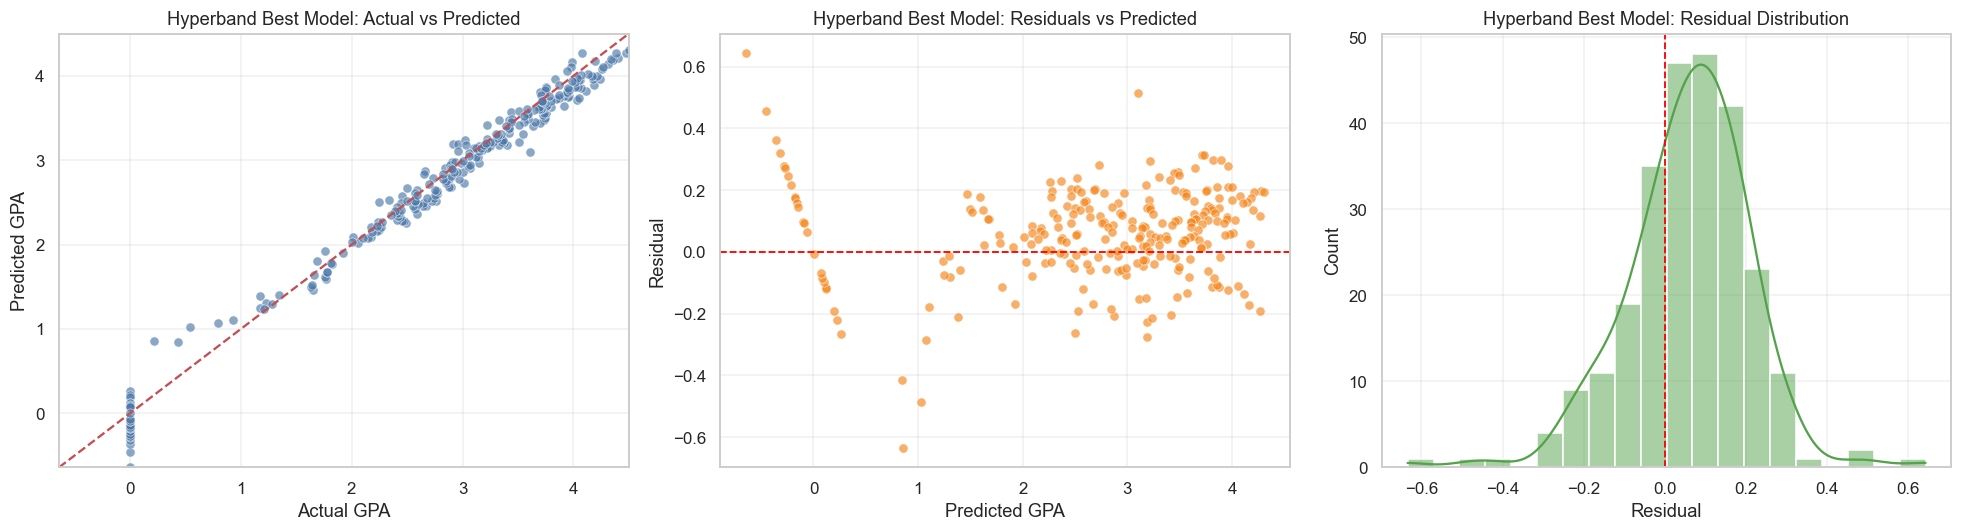

In [58]:
plot_prediction_diagnostics(best_test_df, title_prefix='Hyperband Best Model')

### Experiment 3: Custom Model based on Hyperband Findings

In [59]:
custom_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2},
]

custom_model = build_dense_model(X_train.shape[1], custom_layers)
custom_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 516)                 │          21,156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 516)                 │           2,064 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 516)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │          66,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 90,037 (351.71 KB)

 Trainable params: 88,749 (346.68 KB)

 Non-trainable params: 1,288 (5.03 KB)

In [60]:
custom_model = compile_regression_model(custom_model, optimizer_name='sgd', learning_rate=0.0009)

custom_es, custom_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'custom_model_bayesian.keras',
)

history_custom = custom_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    callbacks=[custom_es, custom_mc],
    verbose=1,
)

Epoch 1/200
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3918 - mae: 0.9340 - r2: -17.0091 - rmse: 1.1752
Epoch 1: val_loss improved from None to 0.39457, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.0736 - mae: 0.8140 - r2: -12.0336 - rmse: 1.0362 - val_loss: 0.3946 - val_mae: 0.5749 - val_r2: -4.0060 - val_rmse: 0.6281
Epoch 2/200
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6040 - mae: 0.6089 - r2: -6.4443 - rmse: 0.7768
Epoch 2: val_loss improved from 0.39457 to 0.05443, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_ba

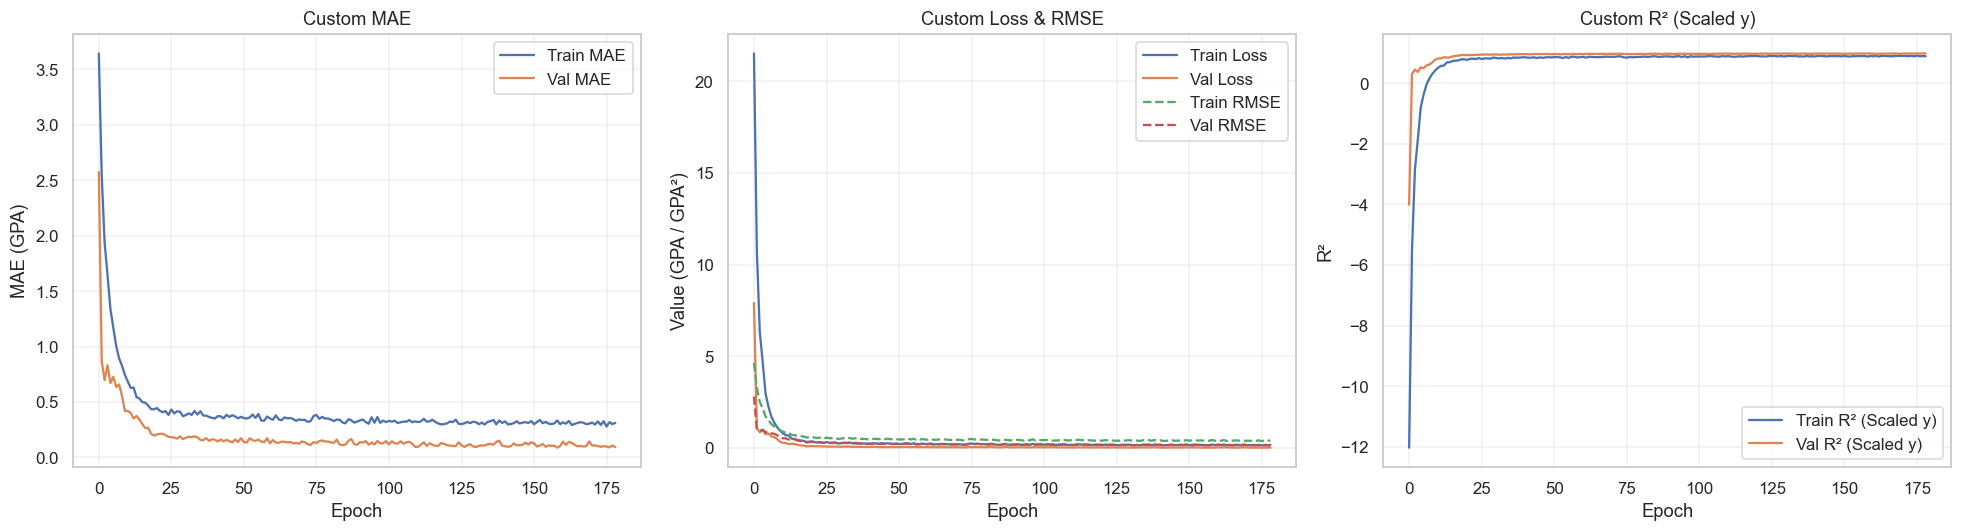


Best Epoch: 159
----------------------------------------
MAE (GPA)   -> Train: 0.3343 | Val: 0.0887
RMSE (GPA)  -> Train: 0.4367 | Val: 0.1399
Loss (GPA²) -> Train: 0.1907 | Val: 0.0196
R² (Scaled y) -> Train: 0.8845 | Val: 0.9876


In [61]:
plot_regression_history(history_custom, title_prefix='Custom')

In [62]:
custom_val_metrics, custom_val_df = evaluate_model_original_scale(
    custom_model, X_val, y_val, scaler, split_name='Custom Validation'
)
custom_test_metrics, custom_test_df = evaluate_model_original_scale(
    custom_model, X_test, y_test, scaler, split_name='Custom Test'
)

custom_summary_df = pd.DataFrame([custom_val_metrics, custom_test_metrics]).set_index('split')
display(format_metrics_display(custom_summary_df))
display(custom_test_df.head(15))

Custom Validation RMSE: 0.1399
Custom Validation MSE:  0.0196
Custom Validation MAE:              0.0887
Custom Validation R² (Original GPA): 0.9876
Custom Validation R² (Scaled y):     0.9876
Custom Test RMSE: 0.1560
Custom Test MSE:  0.0243
Custom Test MAE:              0.0976
Custom Test R² (Original GPA): 0.9831
Custom Test R² (Scaled y):     0.9831


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Custom Validation,0.139946,0.019585,0.088707,0.987602,0.987602
Custom Test,0.155958,0.024323,0.097647,0.983068,0.983068


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,0.974634,-0.974634,0.974634,0.949911
1,0.000000,0.783255,-0.783255,0.783255,0.613489
2,0.217391,0.888061,-0.670669,0.670669,0.449798
3,0.540000,1.169791,-0.629791,0.629791,0.396637
4,0.000000,0.530547,-0.530547,0.530547,0.281480
5,0.428572,0.917477,-0.488906,0.488906,0.239029
6,0.000000,0.403811,-0.403811,0.403811,0.163063
7,0.000000,0.379561,-0.379561,0.379561,0.144066
8,0.000000,0.377383,-0.377383,0.377383,0.142418
9,0.790000,1.166715,-0.376715,0.376715,0.141914


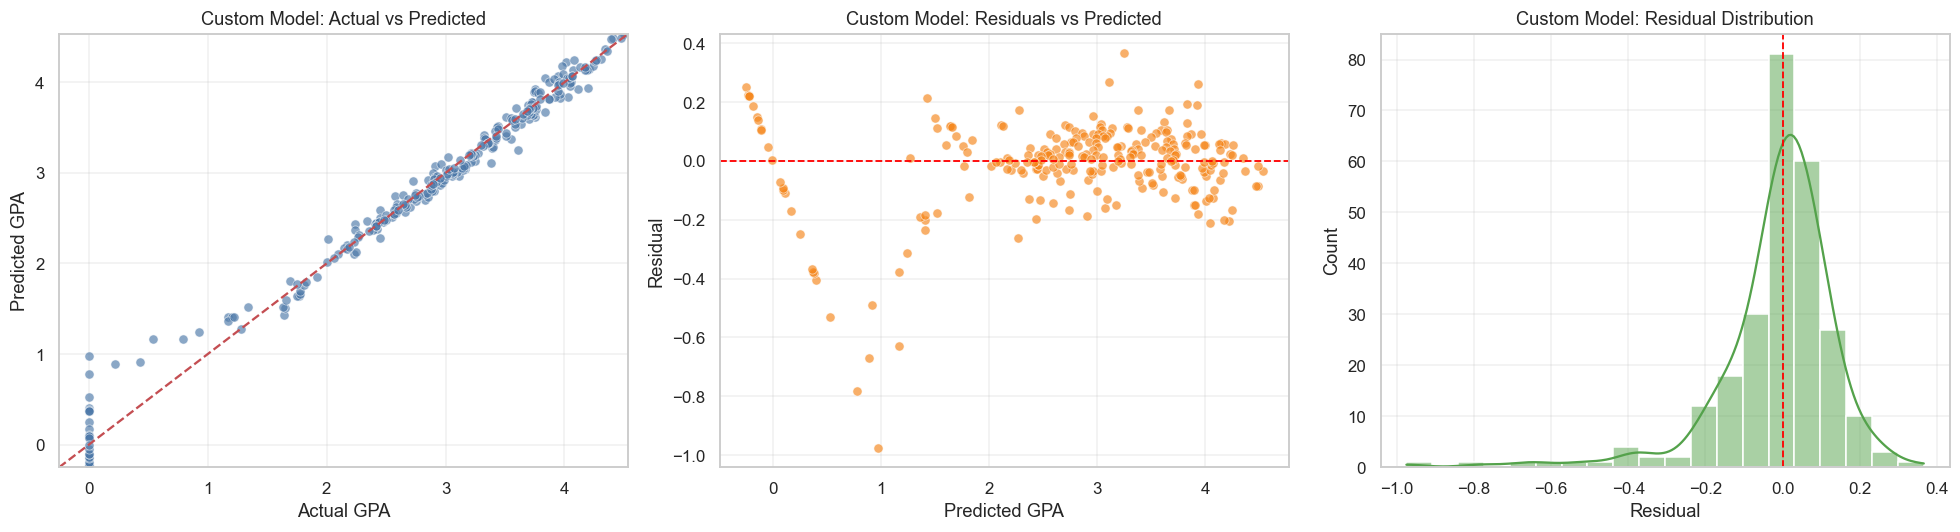

In [63]:
plot_prediction_diagnostics(custom_test_df, title_prefix='Custom Model')

### Experiment 4: Local Search around the Custom Architecture

In [64]:
# trying to find the local minimum around the custom model configuration by varying learning rate and batch size

base_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.10},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.20},
]

local_search_configs = [
    {'trial_name': 'SGD-lr0.00085-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00085, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00088-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00088, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00092-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00092, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00095-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00095, 'batch_size': 64},

    {'trial_name': 'SGD-lr0.00090-bs32', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 32},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00090-bs96', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 96},
    {'trial_name': 'SGD-lr0.00090-bs128', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 128},
]

local_search_results = []
local_search_models = {}
local_search_histories = {}
best_local_model = None
best_local_history = None
best_local_metrics = None
best_local_config = None
best_local_sort_key = None

for trial_idx, config in enumerate(local_search_configs, start=1):
    print_header(config['trial_name'])

    trial_model = build_dense_model(X_train.shape[1], config['layers'])
    trial_model = compile_regression_model(trial_model, optimizer_name=config['optimizer'], learning_rate=config['learning_rate'])

    trial_es = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        mode='min',
    )

    trial_history = trial_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=config['batch_size'],
        callbacks=[trial_es],
        verbose=1,
    )

    trial_val_metrics, _ = evaluate_model_original_scale(
        trial_model, X_val, y_val, scaler, split_name=f"{config['trial_name']} Validation", print_summary=False
    )
    trial_test_metrics, _ = evaluate_model_original_scale(
        trial_model, X_test, y_test, scaler, split_name=f"{config['trial_name']} Test", print_summary=False
    )

    best_epoch = int(np.argmin(trial_history.history['val_loss'])) + 1
    local_result = {
        'trial': trial_idx,
        'trial_name': config['trial_name'],
        'optimizer': config['optimizer'],
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'best_epoch': best_epoch,
        'val_rmse': trial_val_metrics['rmse'],
        'val_mae': trial_val_metrics['mae'],
        'val_r2_original': trial_val_metrics['r2_original'],
        'val_r2_scaled': trial_val_metrics['r2_scaled'],
        'test_rmse': trial_test_metrics['rmse'],
        'test_mae': trial_test_metrics['mae'],
        'test_r2_original': trial_test_metrics['r2_original'],
        'test_r2_scaled': trial_test_metrics['r2_scaled'],
        'architecture': ' | '.join([f"{layer['units']}:{layer['activation']}" for layer in config['layers']]),
    }
    local_search_results.append(local_result)
    local_search_models[config['trial_name']] = trial_model
    local_search_histories[config['trial_name']] = trial_history

    sort_key = (trial_val_metrics['r2_original'], -trial_val_metrics['rmse'])
    if best_local_sort_key is None or sort_key > best_local_sort_key:
        best_local_sort_key = sort_key
        best_local_model = trial_model
        best_local_history = trial_history
        best_local_metrics = local_result
        best_local_config = config

local_search_results_df = pd.DataFrame(local_search_results).sort_values(['val_r2_original', 'val_rmse'], ascending=[False, True]).reset_index(drop=True)
local_search_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'local_search_results_regression_bayesian.csv',
    index=False,
)


========================== SGD-lr0.00085-bs64 ==========================

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 1.3864 - mae: 0.9264 - r2: -15.8312 - rmse: 1.1775 - val_loss: 0.3355 - val_mae: 0.5173 - val_r2: -3.2566 - val_rmse: 0.5792
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.7419 - mae: 0.6592 - r2: -8.0062 - rmse: 0.8613 - val_loss: 0.2136 - val_mae: 0.4163 - val_r2: -1.7103 - val_rmse: 0.4622
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.4622 - mae: 0.5247 - r2: -4.6110 - rmse: 0.6799 - val_loss: 0.0880 - val_mae: 0.2699 - val_r2: -0.1167 - val_rmse: 0.2967
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3746 - mae: 0.4832 - r2: -3.5479 - rmse: 0.6121 - val_loss: 0.0656 - val_mae: 0.2199 - val_r2: 0.1683 - val_rmse: 0.2560
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3183 - mae: 0.4321 - r2: -2.8643 - rmse: 0.5642 - val_loss: 0.0423 - val_mae: 0.1758 - val_r2: 0.4631 - val_rmse: 0.2057
Epoch 

In [65]:
# Save the best local search model
best_local_model.save(project_path / 'second_term_gpa_regression' / 'models' / 'local_search_model_bayesian.keras')

print('BEST LOCAL SEARCH CONFIG')
for key, value in best_local_config.items():
    print(f"{key}: {value}")

display(format_local_search_display(local_search_results_df))

BEST LOCAL SEARCH CONFIG
trial_name: SGD-lr0.00090-bs32
layers: [{'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1}, {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2}]
optimizer: sgd
learning_rate: 0.0009
batch_size: 32


,Trial,Trial Name,Optimizer,Learning Rate,Batch Size,Best Epoch,Val RMSE (GPA),Val MAE (GPA),Val R² (Original GPA),Val R² (Scaled y),Test RMSE (GPA),Test MAE (GPA),Test R² (Original GPA),Test R² (Scaled y),Architecture
0,6,SGD-lr0.00090-bs32,sgd,0.00090,32,198,0.143460,0.091618,0.986972,0.986972,0.153422,0.095418,0.983614,0.983614,516:tanh | 128:elu
1,2,SGD-lr0.00088-bs64,sgd,0.00088,64,198,0.155502,0.094093,0.984693,0.984693,0.174149,0.100323,0.978887,0.978887,516:tanh | 128:elu
2,5,SGD-lr0.00095-bs64,sgd,0.00095,64,178,0.158094,0.094179,0.984179,0.984179,0.198717,0.110816,0.972510,0.972510,516:tanh | 128:elu
3,3,SGD-lr0.00090-bs64,sgd,0.00090,64,199,0.161944,0.103206,0.983399,0.983399,0.189905,0.111509,0.974894,0.974894,516:tanh | 128:elu
4,4,SGD-lr0.00092-bs64,sgd,0.00092,64,196,0.167935,0.106703,0.982148,0.982148,0.191014,0.110869,0.974600,0.974600,516:tanh | 128:elu
5,1,SGD-lr0.00085-bs64,sgd,0.00085,64,188,0.170854,0.105049,0.981522,0.981522,0.177946,0.096748,0.977956,0.977956,516:tanh | 128:elu
6,7,SGD-lr0.00090-bs64,sgd,0.00090,64,194,0.173118,0.098333,0.981029,0.981029,0.188015,0.104055,0.975391,0.975391,516:tanh | 128:elu
7,9,SGD-lr0.00090-bs128,sgd,0.00090,128,192,0.189979,0.120809,0.977153,0.977153,0.232359,0.131851,0.962414,0.962414,516:tanh | 128:elu
8,8,SGD-lr0.00090-bs96,sgd,0.00090,96,200,0.192999,0.117794,0.976421,0.976421,0.203545,0.118192,0.971158,0.971158,516:tanh | 128:elu


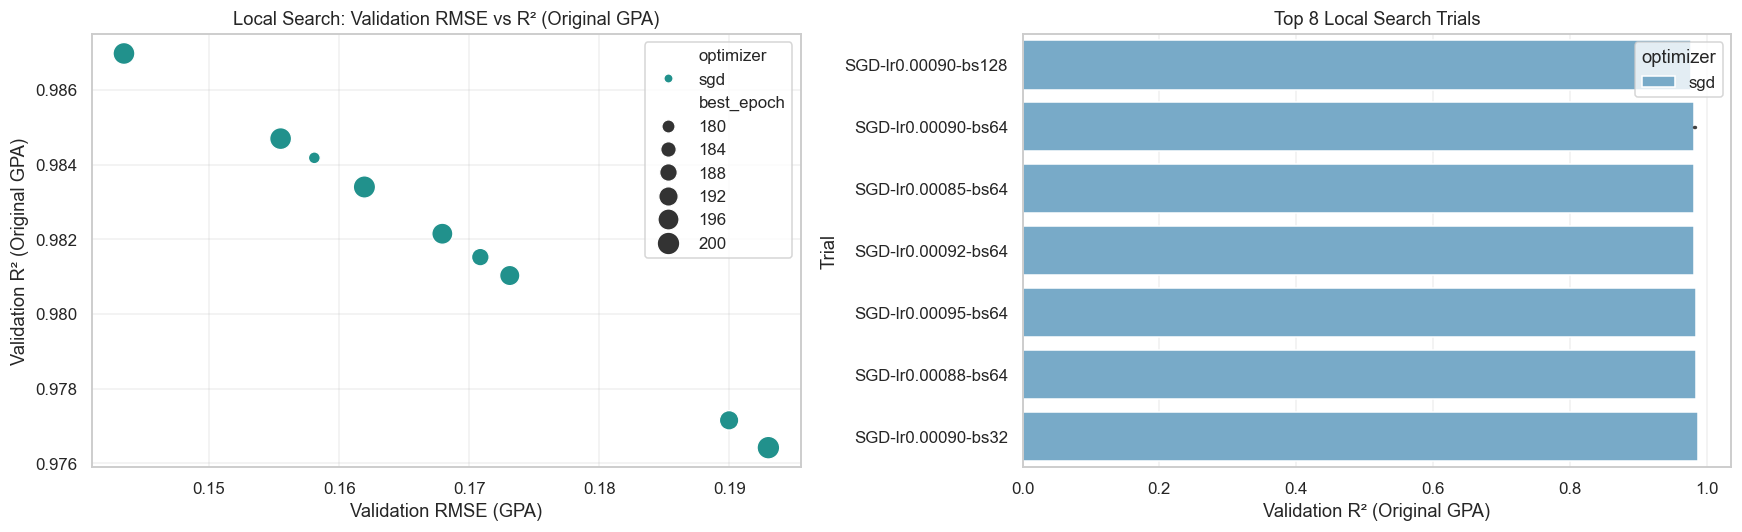

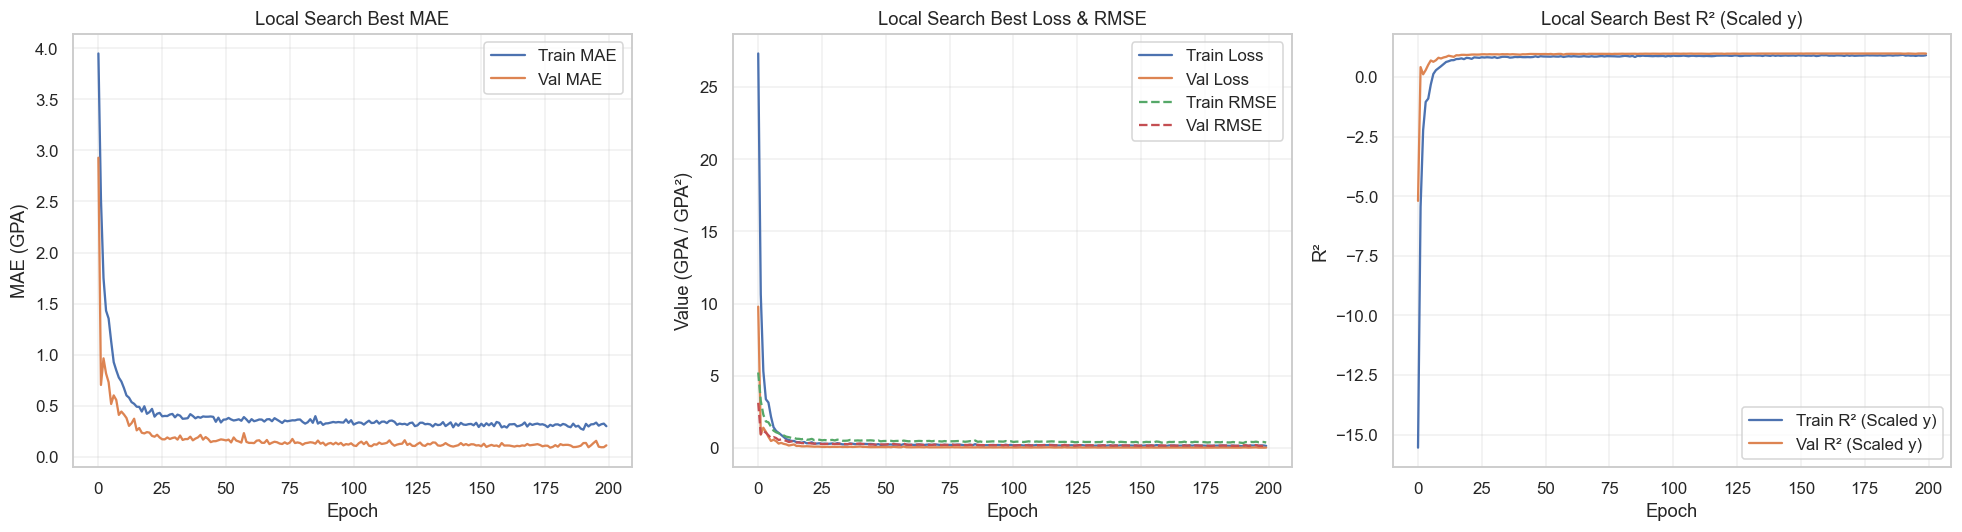


Best Epoch: 198
----------------------------------------
MAE (GPA)   -> Train: 0.3168 | Val: 0.0916
RMSE (GPA)  -> Train: 0.4164 | Val: 0.1435
Loss (GPA²) -> Train: 0.1733 | Val: 0.0206
R² (Scaled y) -> Train: 0.8950 | Val: 0.9870


In [66]:
plot_local_search_summary(local_search_results_df)
plot_regression_history(best_local_history, title_prefix='Local Search Best')

In [67]:
local_val_metrics, local_val_df = evaluate_model_original_scale(
    best_local_model, X_val, y_val, scaler, split_name='Local Search Validation'
)
local_test_metrics, local_test_df = evaluate_model_original_scale(
    best_local_model, X_test, y_test, scaler, split_name='Local Search Test'
)

local_summary_df = pd.DataFrame([local_val_metrics, local_test_metrics]).set_index('split')
display(format_metrics_display(local_summary_df))
display(local_test_df.head(15))

Local Search Validation RMSE: 0.1435
Local Search Validation MSE:  0.0206
Local Search Validation MAE:              0.0916
Local Search Validation R² (Original GPA): 0.9870
Local Search Validation R² (Scaled y):     0.9870
Local Search Test RMSE: 0.1534
Local Search Test MSE:  0.0235
Local Search Test MAE:              0.0954
Local Search Test R² (Original GPA): 0.9836
Local Search Test R² (Scaled y):     0.9836


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Local Search Validation,0.143460,0.020581,0.091618,0.986972,0.986972
Local Search Test,0.153422,0.023538,0.095418,0.983614,0.983614


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,0.889838,-0.889838,0.889838,0.791811
1,0.000000,0.876121,-0.876121,0.876121,0.767587
2,0.000000,0.573107,-0.573107,0.573107,0.328452
3,0.217391,0.765760,-0.548369,0.548369,0.300709
4,0.428572,0.940859,-0.512287,0.512287,0.262438
5,0.000000,0.438369,-0.438369,0.438369,0.192167
6,0.540000,0.972854,-0.432854,0.432854,0.187363
7,0.000000,0.413494,-0.413494,0.413494,0.170977
8,0.000000,-0.409131,0.409131,0.409131,0.167388
9,0.790000,1.194246,-0.404246,0.404246,0.163415


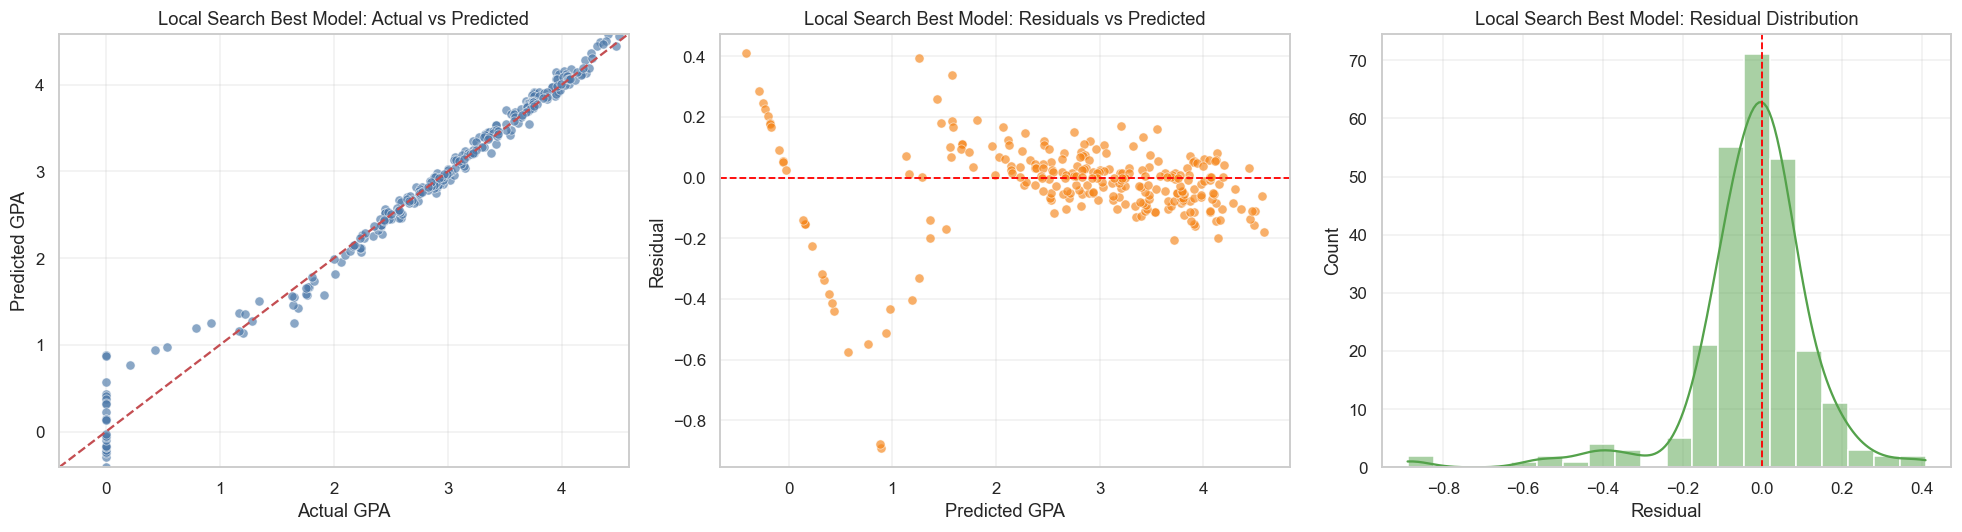

In [68]:
plot_prediction_diagnostics(local_test_df, title_prefix='Local Search Best Model')

### Model Comparison and Grouped Feature Importance

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Baseline,Validation,0.136825,0.018721,0.109105,0.988149,0.988149
1,Baseline,Test,0.145019,0.021030,0.115393,0.985360,0.985360
2,Hyperband Best,Validation,0.158865,0.025238,0.122056,0.984024,0.984024
3,Hyperband Best,Test,0.162781,0.026498,0.127885,0.981553,0.981553
4,Custom,Validation,0.139946,0.019585,0.088707,0.987602,0.987602
5,Custom,Test,0.155958,0.024323,0.097647,0.983068,0.983068
6,Local Search,Validation,0.143460,0.020581,0.091618,0.986972,0.986972
7,Local Search,Test,0.153422,0.023538,0.095418,0.983614,0.983614


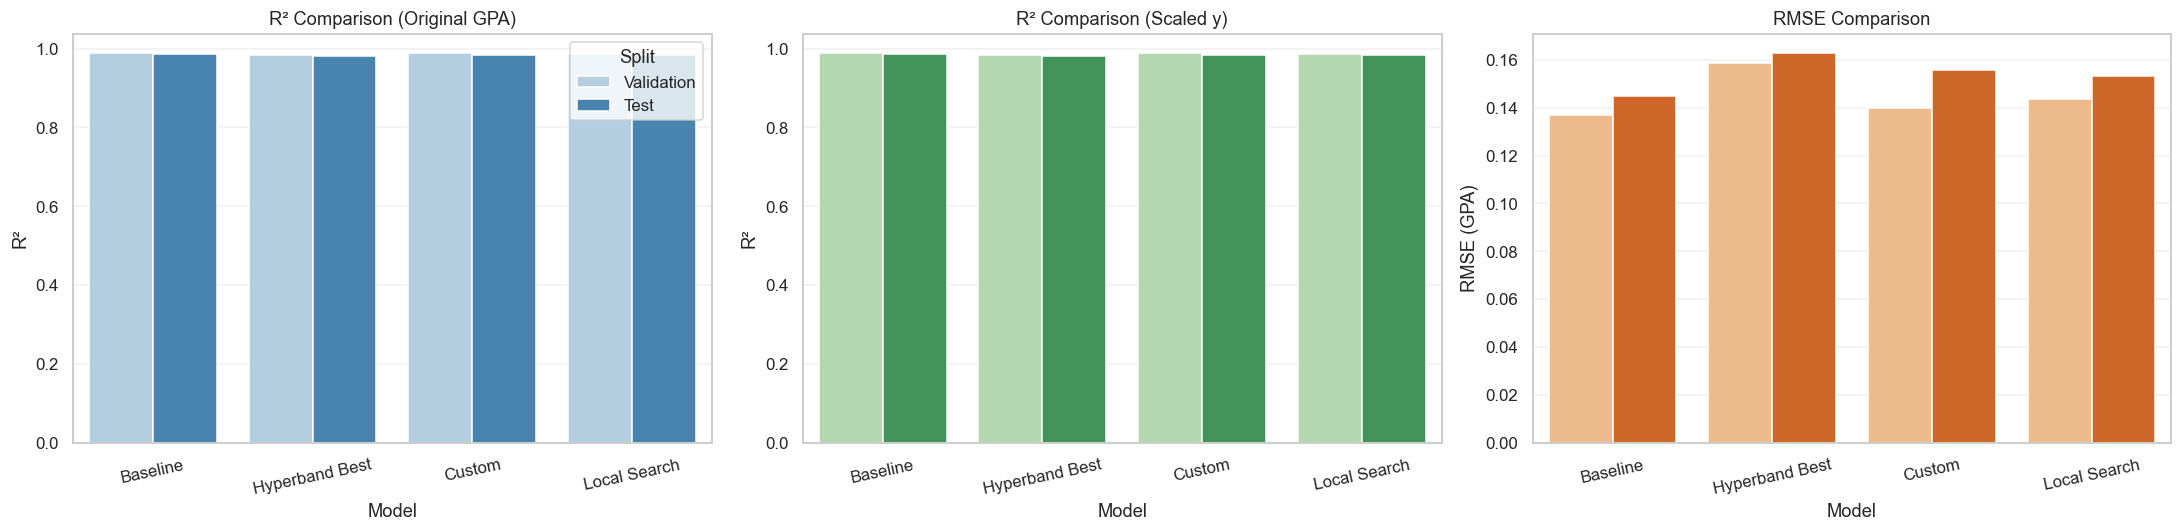

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Baseline,Test,0.145019,0.021030,0.115393,0.985360,0.985360
1,Local Search,Test,0.153422,0.023538,0.095418,0.983614,0.983614
2,Custom,Test,0.155958,0.024323,0.097647,0.983068,0.983068
3,Hyperband Best,Test,0.162781,0.026498,0.127885,0.981553,0.981553


In [69]:
experiment_models = {
    'Baseline': baseline_model,
    'Hyperband Best': best_model,
    'Custom': custom_model,
    'Local Search': best_local_model,
}

comparison_df = pd.DataFrame([
    {'Model': 'Baseline', 'Split': 'Validation', **{k: v for k, v in baseline_val_metrics.items() if k != 'split'}},
    {'Model': 'Baseline', 'Split': 'Test', **{k: v for k, v in baseline_test_metrics.items() if k != 'split'}},
    {'Model': 'Hyperband Best', 'Split': 'Validation', **{k: v for k, v in best_val_metrics.items() if k != 'split'}},
    {'Model': 'Hyperband Best', 'Split': 'Test', **{k: v for k, v in best_test_metrics.items() if k != 'split'}},
    {'Model': 'Custom', 'Split': 'Validation', **{k: v for k, v in custom_val_metrics.items() if k != 'split'}},
    {'Model': 'Custom', 'Split': 'Test', **{k: v for k, v in custom_test_metrics.items() if k != 'split'}},
    {'Model': 'Local Search', 'Split': 'Validation', **{k: v for k, v in local_val_metrics.items() if k != 'split'}},
    {'Model': 'Local Search', 'Split': 'Test', **{k: v for k, v in local_test_metrics.items() if k != 'split'}},
])

display(format_metrics_display(comparison_df))
plot_experiment_comparison(comparison_df)

validation_rank_df = comparison_df[comparison_df['Split'] == 'Test'].sort_values(['r2_original', 'rmse'], ascending=[False, True]).reset_index(drop=True)
display(format_metrics_display(validation_rank_df))

Selected model for grouped feature importance: Baseline


,Feature Group,RMSE Increase (Mean),RMSE Increase (Std),R² Drop (Mean),Grouped Columns
0,first_year_persistence,0.982848,0.053770,0.872940,first_year_persistence
1,second_term_gpa,0.619291,0.008199,0.392079,second_term_gpa
2,first_term_gpa,0.257527,0.013075,0.098286,first_term_gpa
3,gpa_category,0.038202,0.003297,0.008737,"gpa_category_0, gpa_category_1, gpa_category_2..."
4,age_group,0.025432,0.001715,0.005587,age_group
5,residency,0.017445,0.001814,0.003736,residency
6,english_grade,0.014943,0.004466,0.003186,english_grade
7,high_school_average_mark,0.007014,0.000398,0.001451,high_school_average_mark
8,funding,0.004845,0.001632,0.000996,"funding_1, funding_2, funding_4, funding_5, fu..."
9,math_score,0.002407,0.002908,0.000496,math_score


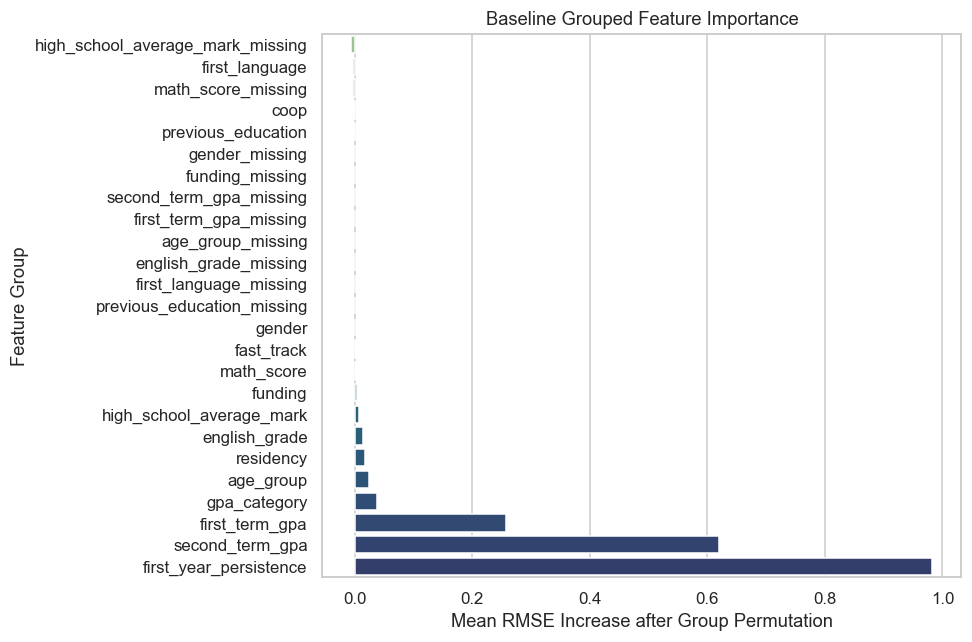

: 

In [ ]:
selected_model_name = validation_rank_df.iloc[0]['Model']
selected_model = experiment_models[selected_model_name]
print(f'Selected model for grouped feature importance: {selected_model_name}')

grouped_importance_df = compute_grouped_permutation_importance(
    selected_model,
    X_test,
    y_test,
    scaler,
    n_repeats=3,
    random_state=42,
)

display(grouped_importance_df)
plot_grouped_feature_importance(
    grouped_importance_df,
    title=f'{selected_model_name} Grouped Feature Importance',
)